# Data Exploration — Merged Naira Dataset (V1, raw)

Before I touch any preprocessing or re-splitting, I want to understand exactly what the merge actually gave me: did combining the three sources fix the class imbalance I saw in the baseline (₦20 and ₦50 were badly underrepresented), and did the merge introduce any new problems — mismatched folder structures, corrupted files, or duplicate images that could quietly leak between train and test later.

This notebook only *looks* — no files get moved, split, or deleted here. Splitting and cleanup are deliberately left for a separate preprocessing notebook so this one stays a clean, reproducible record of what the raw merged data looks like.


## 1. Confirm the dataset path resolves

First thing — just checking the merged folder actually exists at the path I expect, before running anything that depends on it.


In [2]:
from pathlib import Path

DATASET_ROOT = Path(r"E:/merged V1")  # or Path("E:/merged V1") — forward slashes also work on Windows
print(DATASET_ROOT.exists())

True


## 2. Check the folder structure

I merged three datasets as raw files (no train/val/test split applied), so I want to see what's actually sitting under `merged V1` before assuming anything about the layout.


In [2]:
for split_dir in sorted(DATASET_ROOT.iterdir()):
    if split_dir.is_dir():
        classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
        print(f"{split_dir.name}: {classes}")

Raw: ['10 naira', '100 naira', '1000 naira', '20 naira', '200 naira', '5 naira', '50 naira', '500 naira']


Everything sits under a single `Raw` folder, and inside that are the 8 denomination folders I expect — `10 naira`, `100 naira`, `1000 naira`, `20 naira`, `200 naira`, `5 naira`, `50 naira`, `500 naira`. No leftover split folders from any of the three source datasets, which means the merge is clean at the structural level — I don't need to reconcile different folder-naming conventions before going further.


## 3. Count images per class

This is the number I actually care about most right now — whether the merge fixed the ₦20 / ₦50 shortage that hurt the baseline model (those two classes only had ~12 test images each and were the weakest performers).


In [3]:
import pandas as pd

records = []
for split_dir in DATASET_ROOT.iterdir():
    if not split_dir.is_dir():
        continue
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
        count = len(list(class_dir.glob("*")))
        records.append({"split": split_dir.name, "class": class_dir.name, "count": count})

df = pd.DataFrame(records)
pivot = df.pivot(index="class", columns="split", values="count").fillna(0).astype(int)
pivot["total"] = pivot.sum(axis=1)
pivot.sort_values("total")

split,Raw,total
class,,
5 naira,243,243
10 naira,245,245
20 naira,333,333
200 naira,336,336
1000 naira,372,372
100 naira,453,453
50 naira,455,455
500 naira,459,459


**2,896 images total across 8 classes** — a solid jump from the baseline's ~1,700. More importantly, ₦20 went from being one of the thinnest classes to a respectable **333 images**, and ₦50 is now at **455**, actually one of the *better*-represented classes in the merged set. ₦5 (243) and ₦10 (245) are now the smallest classes instead — worth keeping an eye on once I get to the stratified split, but nowhere near as thin as ₦20 used to be. This is a genuinely encouraging sign that the merge targeted the right gap.

## 4. Check image formats and color modes

Merging datasets from different sources usually means inconsistent file formats and color modes, which can cause silent problems later (e.g. an RGBA image breaking a preprocessing step built for RGB). I'm sampling 300 images at random rather than checking all ~2,900 — just a quick spot-check rather than a full audit at this stage.


In [4]:
from PIL import Image
import random

sample_paths = list(DATASET_ROOT.rglob("*.*"))
sample = random.sample(sample_paths, min(300, len(sample_paths)))

props = []
for p in sample:
    try:
        with Image.open(p) as img:
            props.append({"path": str(p), "format": img.format, "mode": img.mode, "size": img.size})
    except Exception as e:
        props.append({"path": str(p), "format": "ERROR", "mode": str(e), "size": None})

props_df = pd.DataFrame(props)
print(props_df["format"].value_counts())
print(props_df["mode"].value_counts())

format
JPEG    299
PNG       1
Name: count, dtype: int64
mode
RGB     299
RGBA      1
Name: count, dtype: int64


Out of the 300-image sample, 299 are JPEG/RGB and just 1 is PNG/RGBA. That's about as clean as a merged dataset gets — I don't need a format-normalization step before training, though I'll want to make sure that lone RGBA image (and any others like it across the full set) gets converted to RGB during preprocessing so it doesn't break the model's expected input shape.


## 5. Scan for corrupted files

Before doing anything else, I want to rule out broken images — a corrupted file can crash a training run partway through, which is a lot more annoying to debug mid-training than catching it now.


In [5]:
from tqdm import tqdm

bad_files = []
all_images = list(DATASET_ROOT.rglob("*.*"))
for p in tqdm(all_images):
    try:
        with Image.open(p) as img:
            img.verify()
    except Exception:
        bad_files.append(p)

print(f"{len(bad_files)} corrupted files found")
bad_files[:20]

100%|██████████| 2896/2896 [03:41<00:00, 13.07it/s]

0 corrupted files found


[]

**Zero corrupted files** across all 2,896 images. One less thing to worry about going into preprocessing.

## 6. Check for duplicate / near-duplicate images

This is the check that matters most before I split the data — if the same (or a near-identical) image shows up more than once because two of my three source datasets happened to scrape overlapping images, and those duplicates end up split across train and test, my evaluation numbers later would be misleadingly high. Better to know about this now, while everything is still one raw pool, rather than after splitting.


In [6]:
import imagehash

hashes = {}
dupes = []
for p in tqdm(all_images):
    try:
        h = imagehash.average_hash(Image.open(p))
        if h in hashes:
            dupes.append((p, hashes[h]))
        else:
            hashes[h] = p
    except Exception:
        continue

print(f"{len(dupes)} likely duplicate pairs found")
dupes[:10]

100%|██████████| 2896/2896 [20:00<00:00,  2.41it/s]  


302 likely duplicate pairs found


[(WindowsPath('E:/merged V1/Raw/5 naira/5-back-27.jpg'),
  WindowsPath('E:/merged V1/Raw/5 naira/5-back-24.jpg')),
 (WindowsPath('E:/merged V1/Raw/5 naira/5_25.jpeg'),
  WindowsPath('E:/merged V1/Raw/5 naira/5_4.jpeg')),
 (WindowsPath('E:/merged V1/Raw/5 naira/5_119.jpeg'),
  WindowsPath('E:/merged V1/Raw/5 naira/5_27.jpeg')),
 (WindowsPath('E:/merged V1/Raw/5 naira/5_120.jpeg'),
  WindowsPath('E:/merged V1/Raw/5 naira/5_4.jpeg')),
 (WindowsPath('E:/merged V1/Raw/5 naira/5_126.jpeg'),
  WindowsPath('E:/merged V1/Raw/5 naira/5_117.jpeg')),
 (WindowsPath('E:/merged V1/Raw/5 naira/5_128.jpeg'),
  WindowsPath('E:/merged V1/Raw/5 naira/5_122.jpeg')),
 (WindowsPath('E:/merged V1/Raw/5 naira/5_129.jpeg'),
  WindowsPath('E:/merged V1/Raw/5 naira/5_27.jpeg')),
 (WindowsPath('E:/merged V1/Raw/5 naira/5_134.jpeg'),
  WindowsPath('E:/merged V1/Raw/5 naira/5_4.jpeg')),
 (WindowsPath('E:/merged V1/Raw/10 naira/10_5.jpeg'),
  WindowsPath('E:/merged V1/Raw/10 naira/10_4.jpeg')),
 (WindowsPath('E:/merg

**302 likely duplicate pairs** flagged out of 2,896 images — a meaningful chunk (~10%). Looking at the first few hits, they're concentrated in ₦5 and ₦10 so far, which lines up with those being the smaller classes — possibly the same physical notes photographed multiple times, or overlapping images pulled in by more than one of the three merged sources.

One caveat I want to keep in mind: `average_hash` is a fairly loose perceptual hash — it can flag visually similar-but-genuinely-different images (e.g. two different notes photographed at a similar angle against a similar background) as "duplicates" when they aren't actually the same image. Before I act on this list in the preprocessing notebook, it's worth spot-checking a sample of these pairs visually to confirm they're true duplicates and not false positives, rather than blindly dropping all 302 pairs.

## 7. Early attempt at a sample image grid (superseded)

This was my first attempt at pulling sample images per class, still written from when I assumed the data was already split into `Train`/`val`/`Test` folders. Since the raw merge doesn't have that structure — everything sits directly under `Raw/<class>/` — this cell runs without error but doesn't actually find any images (the `Train` subfolder it's looking for doesn't exist), so the grid renders empty. I'm leaving it here as a record of the debugging process rather than deleting it; the working version is further down once I corrected the path assumption.


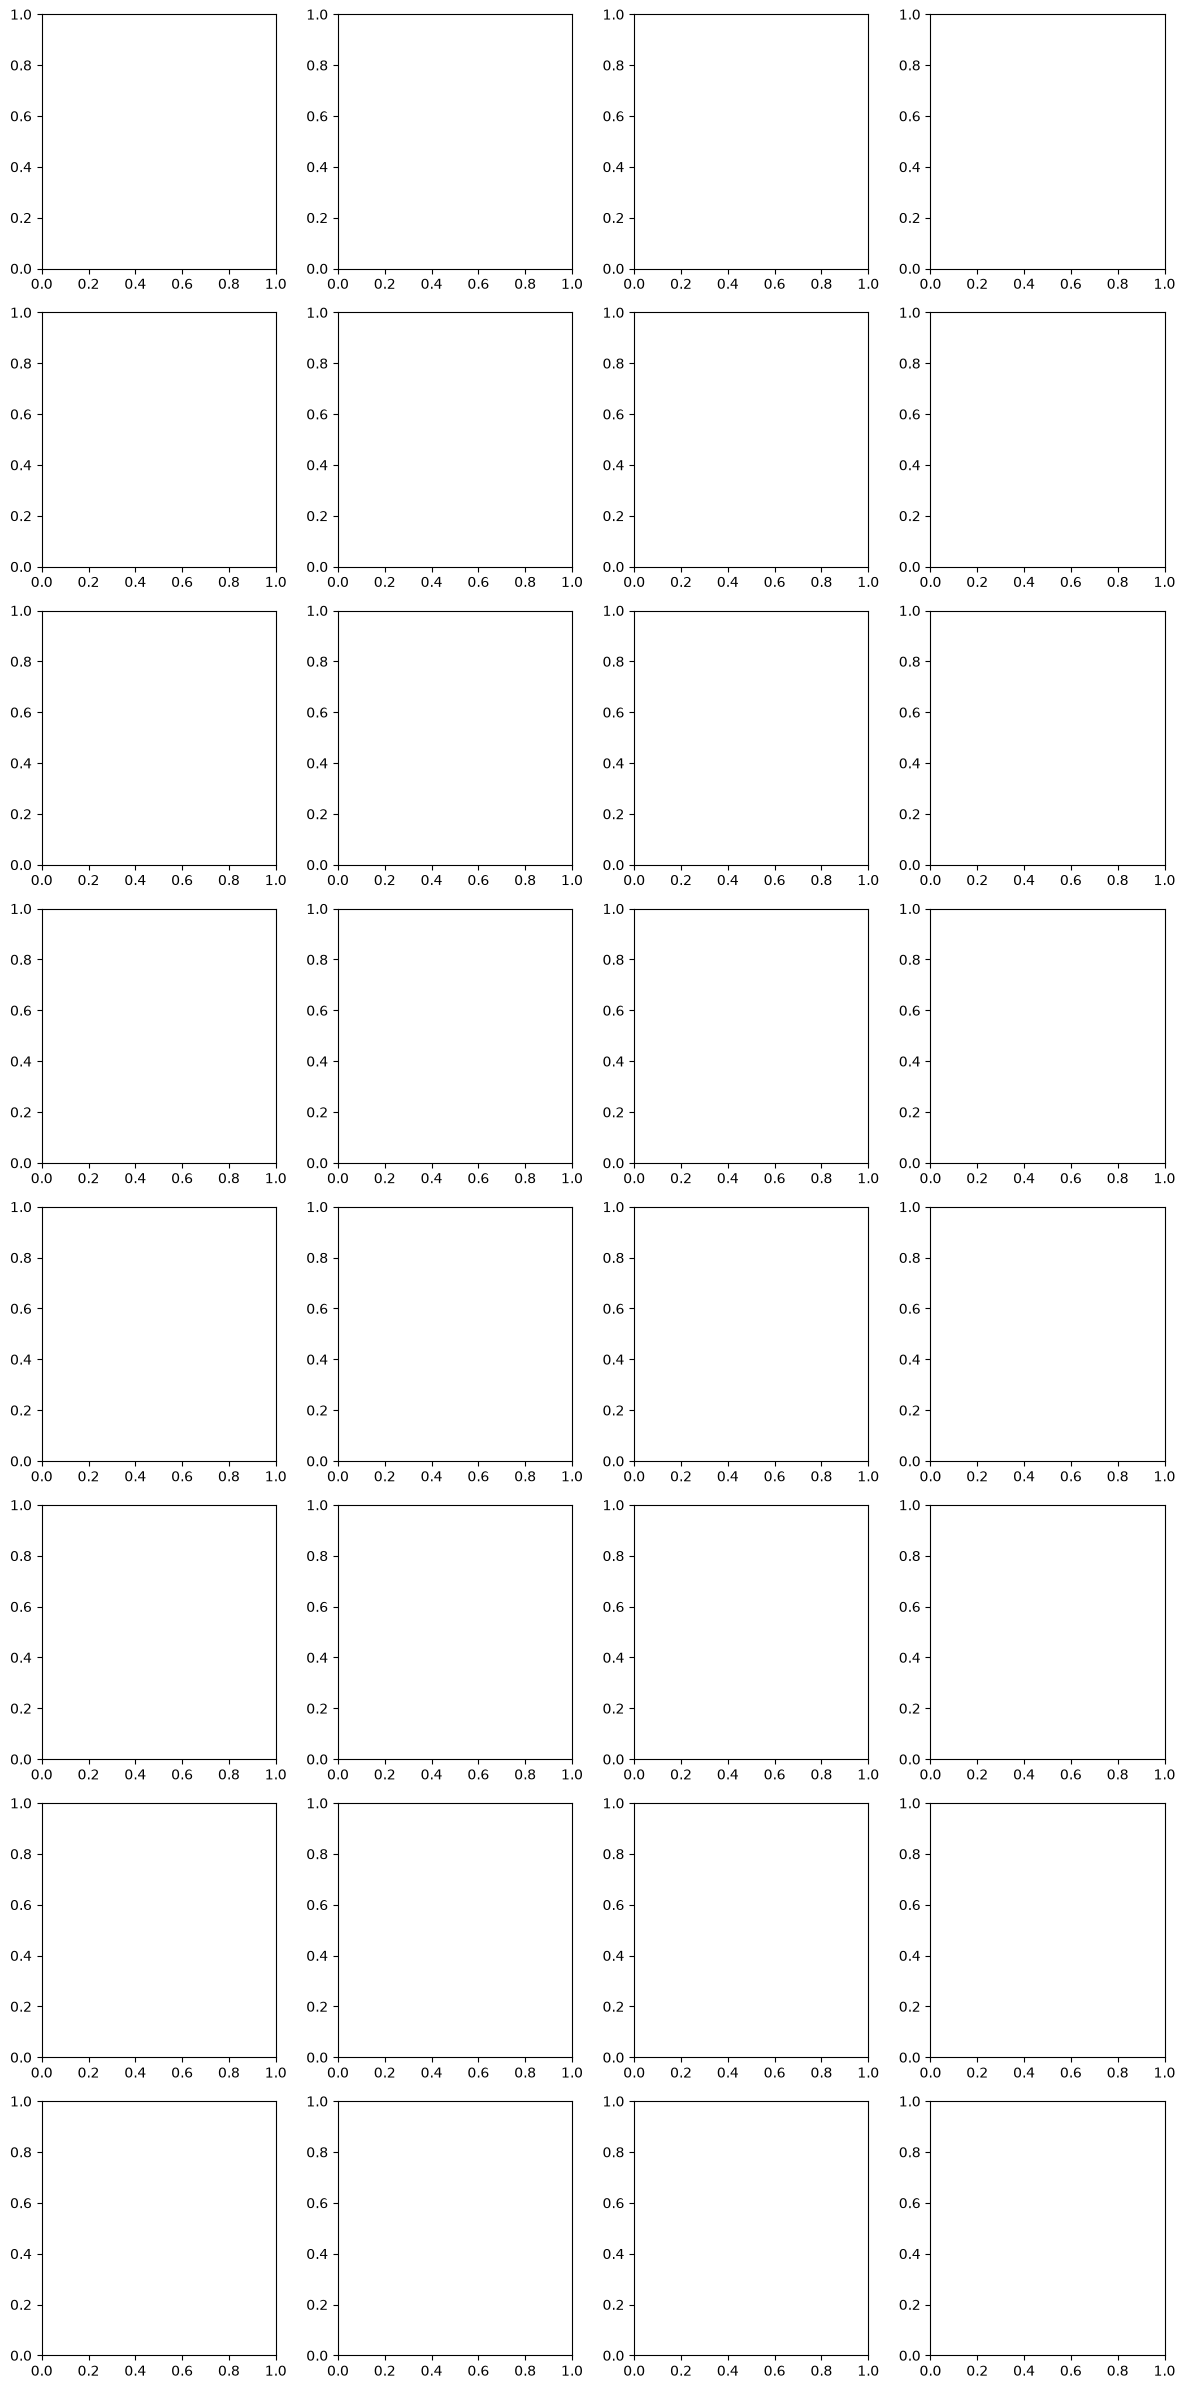

In [13]:

import matplotlib.pyplot as plt

classes = pivot.index.tolist()
fig, axes = plt.subplots(len(classes), 4, figsize=(12, 3*len(classes)))

for i, cls in enumerate(classes):
    class_imgs = list((DATASET_ROOT / "Train" / cls).glob("*"))[:4]  # adjust split name if needed
    for j, img_path in enumerate(class_imgs):
        img = Image.open(img_path)
        axes[i,j].imshow(img)
        axes[i,j].axis("off")
        if j == 0:
            axes[i,j].set_ylabel(cls, rotation=0, labelpad=40)

plt.tight_layout()
plt.show()

## 8. Total images per class — bar chart

A quick visual on the class counts from Section 3, since a sorted bar is a faster read than scanning the pivot table — and this is the chart that directly answers "did the merge actually fix the imbalance."


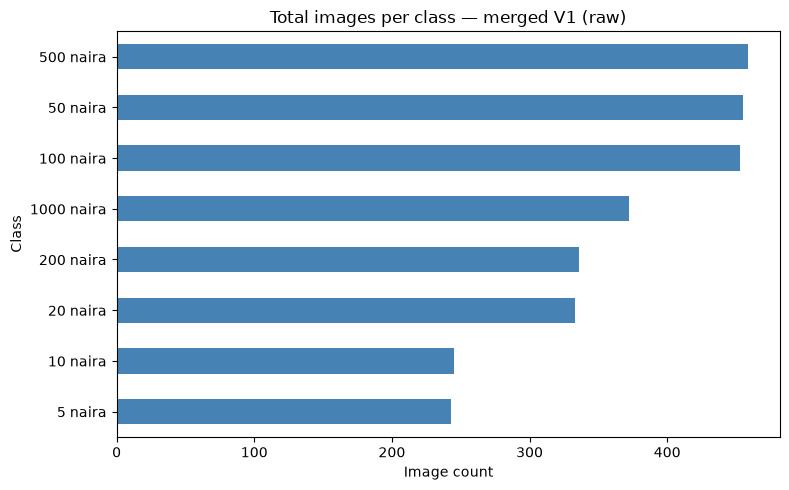

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

RAW_ROOT = DATASET_ROOT / "Raw"  # class folders live one level deeper than DATASET_ROOT

records = []
for class_dir in RAW_ROOT.iterdir():
    if class_dir.is_dir():
        records.append({
            "class": class_dir.name,
            "count": len(list(class_dir.glob("*")))
        })

pivot = pd.DataFrame(records).set_index("class").sort_index()

pivot["count"].sort_values().plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.title("Total images per class — merged V1 (raw)")
plt.xlabel("Image count")
plt.ylabel("Class")
plt.tight_layout()
plt.show()


## Total images per class — bar chart 

With `RAW_ROOT` pointing at the right depth, the chart now renders properly and confirms the numbers from Section 3: **500 naira (459) and 50 naira (455) are the best-represented classes**, followed closely by 100 naira (453). At the other end, **5 naira (243) and 10 naira (245) are now the smallest classes** — a genuine reversal from the baseline, where 20 naira and 50 naira were the ones dragging the model down.

The gap between the largest and smallest class is roughly 2x (459 vs 243), which is a manageable imbalance — nowhere near the kind of severe skew that would demand class weighting or oversampling before training. Still, I'll want to keep 5 naira and 10 naira in mind when I do the stratified split, so neither ends up with too few samples in the validation or test sets to give a reliable per-class read.

**Bottom line: the merge did what I needed it to do.** ₦20 and ₦50 — the two classes that were nearly unusable in the baseline — are now solidly mid-to-top of the pack. The class-balance problem has effectively shifted rather than disappeared (₦5/₦10 are the new smallest), but it's a much shallower imbalance than before, and shouldn't need special handling beyond making sure the stratified split respects it.

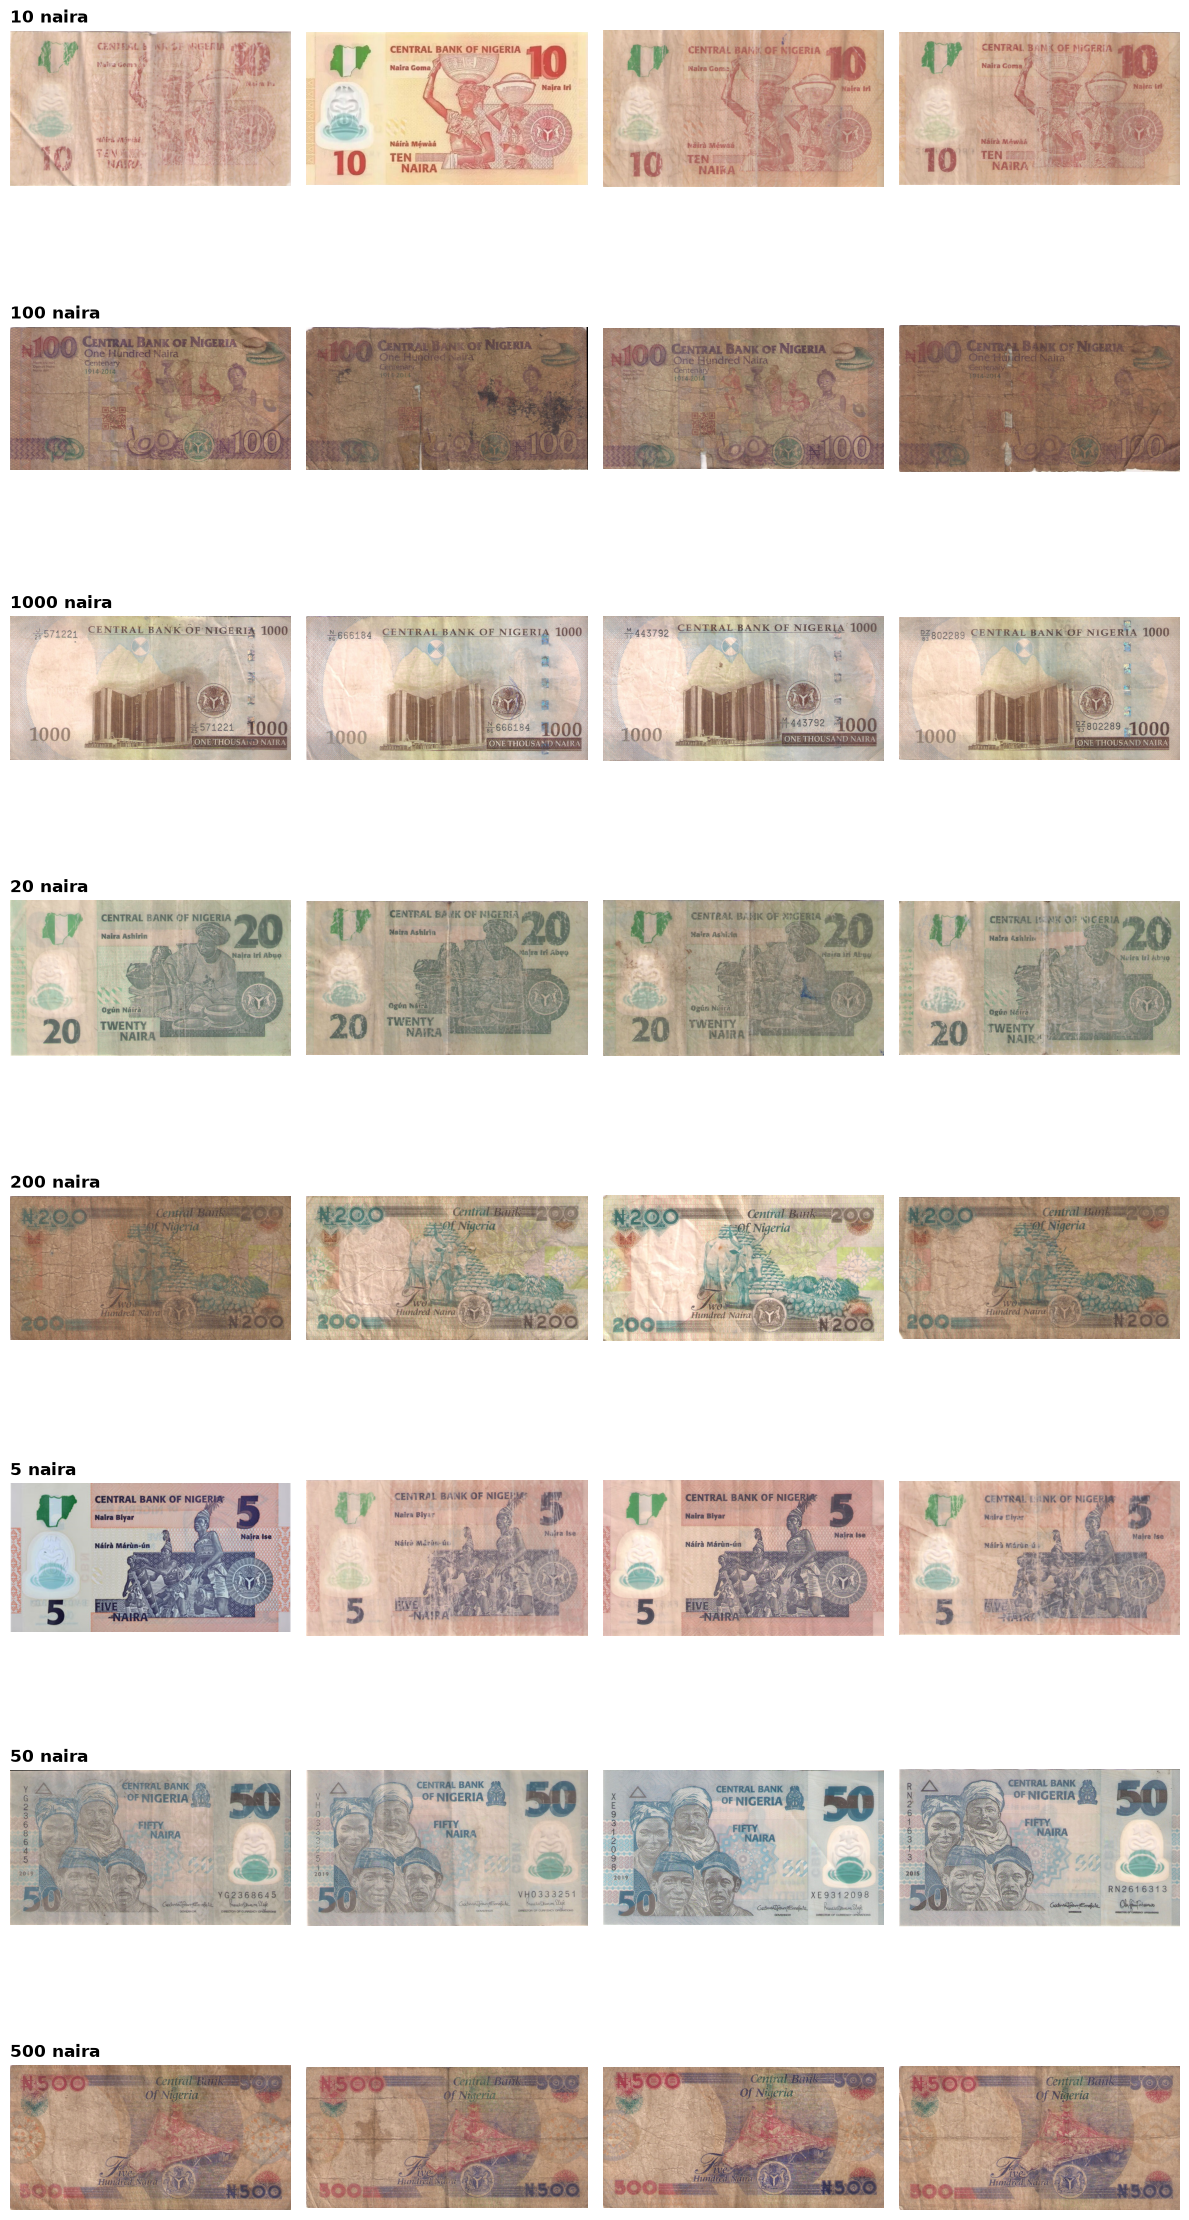

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
n_samples = 4

classes = sorted([d.name for d in RAW_ROOT.iterdir() if d.is_dir()])

def get_sample_images(class_dir, n):
    imgs = [p for p in class_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS]
    return imgs[:n]

fig, axes = plt.subplots(len(classes), n_samples, figsize=(3*n_samples, 3*len(classes)))
axes = np.atleast_2d(axes)

for i, cls in enumerate(classes):
    class_imgs = get_sample_images(RAW_ROOT / cls, n_samples)
    for j in range(n_samples):
        ax = axes[i, j]
        if j < len(class_imgs):
            try:
                img = Image.open(class_imgs[j])
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "unreadable", ha="center", va="center")
        ax.axis("off")
        if j == 0:
            ax.set_title(cls, loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## Sample grid — visual review across all 8 classes

Going class by class, a few things stand out immediately:

**Orientation is consistent.** Every class shows the *back* of the note, not a mix of front/back — that's actually reassuring rather than something to fix, since it means the model will learn one consistent view per class rather than two different visual patterns under a single label.

**Wear and condition vary a lot within each class**, which is good — I've got crisp, near-new notes (₦1000, most of ₦100) sitting right next to heavily worn, creased, and stained ones (₦100's second and fourth samples especially). That's the kind of real-world variation I want in training data rather than a dataset of only pristine notes.



**The watermark/security-thread ghosting in the bottom-left corner is present across nearly every image, in every class** — that's likely just how these were photographed (flash reflecting off the security feature) rather than a labeling issue, but worth keeping in mind since it means the model may partly be learning to recognize *that artifact's position* rather than purely the note's actual design.




## Final conclusion — Data Exploration (Merged V1, raw)

Pulling everything from this notebook together:

**Volume and balance.** The merge brought the dataset from ~1,700 images (baseline) up to **2,896 images across 8 classes**. More importantly, it fixed the exact problem I set out to fix — ₦20 (333) and ₦50 (455), the two weakest classes in the baseline model, are now solidly mid-to-top of the pack. ₦5 (243) and ₦10 (245) are the new smallest classes, but the largest-to-smallest gap is only about 2x, which is a manageable imbalance rather than a severe one.

**Data quality.** Zero corrupted files across all 2,896 images. Format/mode is almost entirely uniform (299/300 sampled images are JPEG/RGB, one stray PNG/RGBA to normalize). Structurally, the merge is clean — one `Raw` folder, 8 correctly named class folders, no leftover split directories from the three source datasets.

**Open item: possible duplicates.** 302 likely duplicate pairs were flagged via perceptual hashing (~10% of the dataset), concentrated in ₦5 and ₦10 so far. Since `average_hash` can produce false positives on genuinely different but visually similar images, this needs a visual spot-check before I decide how much of it to actually dedupe — but it has to happen *before* the stratified split, since duplicates left in place could otherwise get scattered across train and test and quietly inflate evaluation numbers.

**Visual review.** Sample grids across all 8 classes show good real-world variation in note condition (crisp to heavily worn) and consistent orientation (back of note throughout), which is exactly the kind of variation that should help generalization once trained.

### What this means for the next notebook (preprocessing)

1. Spot-check and resolve the 302 flagged duplicate pairs
2. Normalize the one RGBA image to RGB
3. Run the stratified train/val/test split (70/15/15 or 80/10/10) on the cleaned pool
4. Re-run the cross-split duplicate check afterward to confirm no leakage

The dataset is in solid shape overall — the merge did what it needed to do on class balance, and the only real cleanup item before splitting is resolving the duplicate question.